# **🚢 Titanic Survival Prediction Using Machine Learning**
### **By--Amit Kumar**

# **Import Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# **Load Dataset**

In [51]:
df = pd.read_csv("Titanic-Dataset.csv")

# **Dataset Overview**

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.shape

(891, 12)

In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **Missing Values**

In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# **Statistical Summary**

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Data Cleaning**

**Age**

In [14]:
df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

**Embarked**

In [15]:
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

**Cabin**

In [16]:
df.drop(
    'Cabin',
    axis=1,
    inplace=True
)

**Verify**

In [17]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# **Survival Distribution**

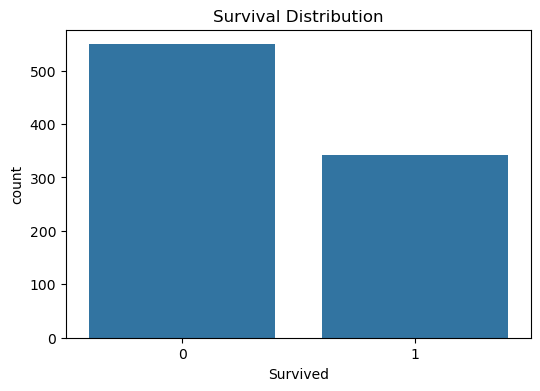

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Distribution")

plt.show()

# **Gender Distribution**

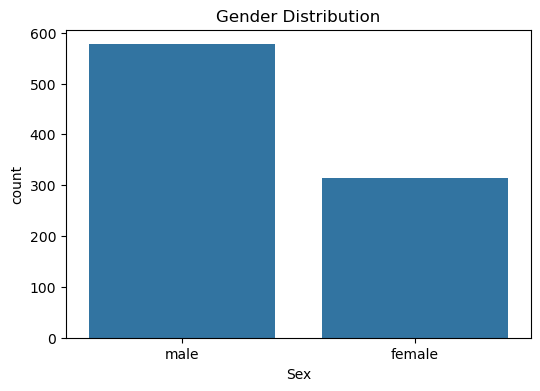

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    data=df
)

plt.title("Gender Distribution")

plt.show()

# **Survival by Gender**

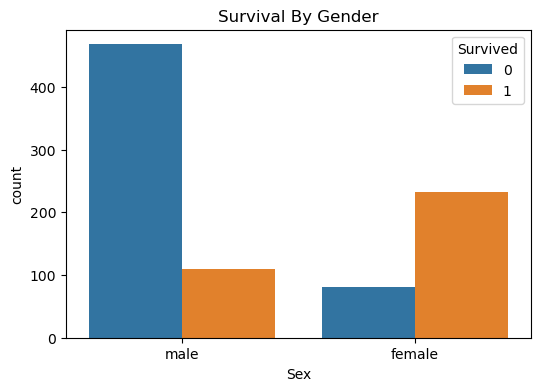

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival By Gender")

plt.show()

# **Passenger Class Distribution**

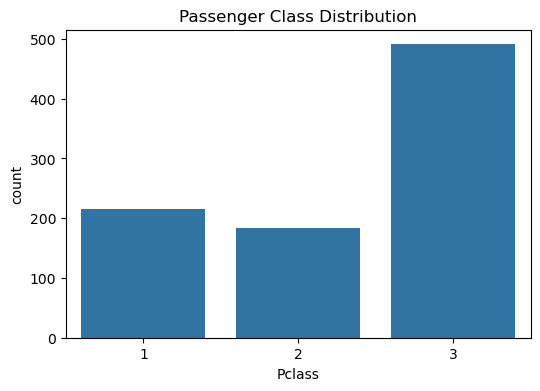

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    data=df
)

plt.title("Passenger Class Distribution")

plt.show()

# **Survival Rate by Passenger Class**

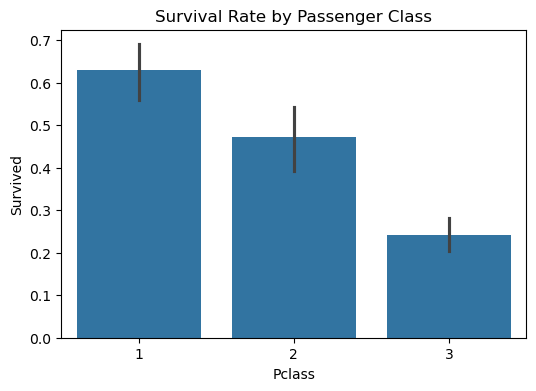

In [22]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")

plt.show()

# **Age Distribution**

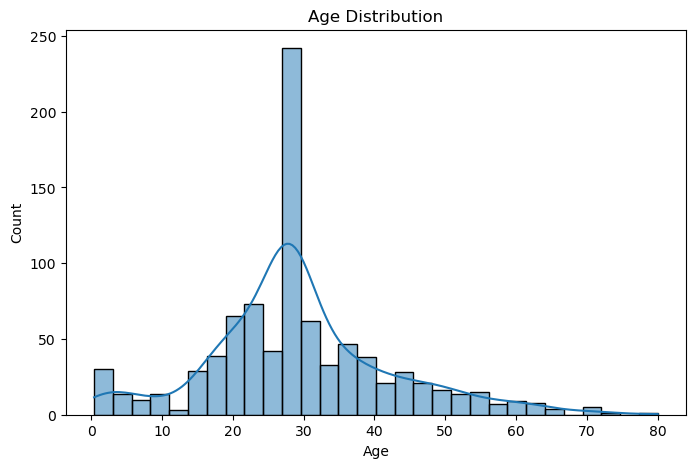

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

# **Fare Distribution**

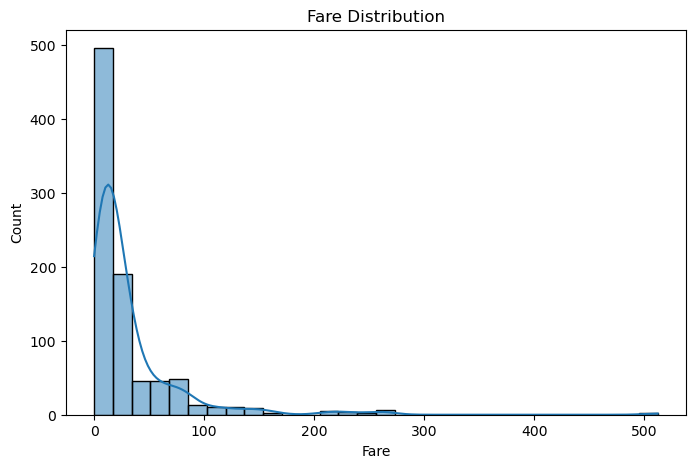

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Fare'],
    bins=30,
    kde=True
)

plt.title("Fare Distribution")

plt.show()

# **Correlation Heatmap**

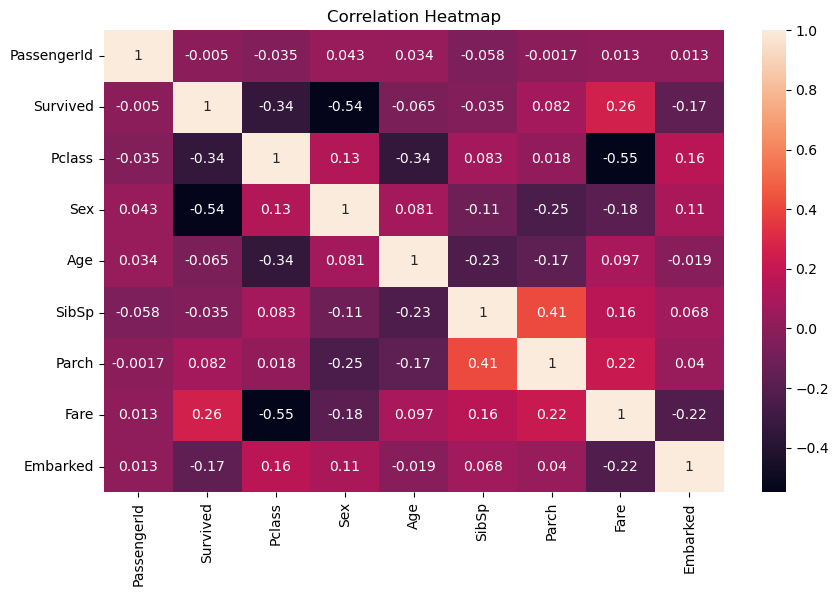

In [25]:
temp_df = df.copy()

le = LabelEncoder()

temp_df['Sex'] = le.fit_transform(
    temp_df['Sex']
)

temp_df['Embarked'] = le.fit_transform(
    temp_df['Embarked']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    temp_df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# **Feature Engineering**

In [26]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(
    df['Sex']
)

df['Embarked'] = encoder.fit_transform(
    df['Embarked']
)

# **Drop Unnecessary Columns**

In [27]:
df.drop(
    ['PassengerId',
     'Name',
     'Ticket'],
    axis=1,
    inplace=True
)

# **Features and Target**

In [28]:
X = df.drop(
    'Survived',
    axis=1
)

y = df['Survived']

# **Train Test Split**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **Model Training**

**Logistic Regression**

In [30]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 81.01 %


**Decision Tree**

In [31]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy*100,2),
    "%"
)

Decision Tree Accuracy: 78.21 %


**Random Forest**

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Imports Successful")

Imports Successful


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 82.12 %


# **Model Comparison table**

In [34]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
2,Random Forest,0.821229


# **Model Comparison Graph**

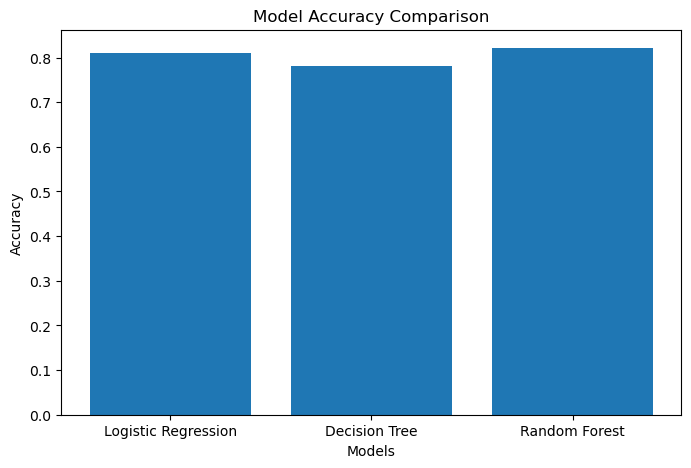

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

**Best Model**

In [36]:
best_model = comparison.iloc[0]

print("Best Performing Model")
print("----------------------")
print("Model :", best_model['Model'])
print("Accuracy :", round(best_model['Accuracy']*100,2), "%")

Best Performing Model
----------------------
Model : Logistic Regression
Accuracy : 81.01 %


# Model Comparison Analysis

Three machine learning models were trained and evaluated:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Among these models, the model with the highest accuracy was selected as the best-performing model for Titanic survival prediction.

This comparison helps in understanding how different algorithms perform on the same dataset and allows selection of the most suitable model.

# **Predictions**

In [44]:
y_pred = lr_model.predict(
    X_test
)

# **Accuracy Score**

In [45]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 81.01 %


# **Classification Report**

In [46]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



# **Confusion Matrix**

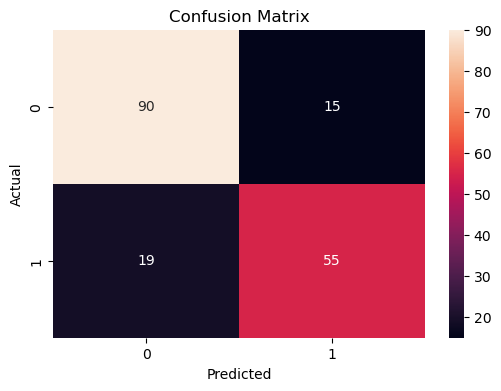

In [47]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **Feature Importance**

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

importance

,Feature,Coefficient
5,Fare,0.002534
2,Age,-0.030433
4,Parch,-0.111854
6,Embarked,-0.218777
3,SibSp,-0.293905
0,Pclass,-0.930680
1,Sex,-2.596994


# **Sample Prediction**

In [50]:
sample = [[
    3,
    1,
    25,
    0,
    0,
    7.25,
    2
]]

prediction = lr_model.predict(
    sample
)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Did Not Survive


C:\Users\amitk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
